# Video Object Segmentation on Shorts-style clips: YOLO11-seg vs Mask R-CNN

**Goal:** take free, vertical (9:16) stock videos, segment every object in each frame with **two different computer-vision libraries**, and render a **YouTube-Shorts-sized (1080x1920) split-screen video**. Model A is on the top half and model B on the bottom half, so you can compare them on the same footage.

### How this relates to the article
The article [*The Basics of Video Object Segmentation*](https://medium.com/@eddiesmo/video-object-segmentation-the-basics-758e77321914) frames the task as **pixel-level object tracking** and splits it into:

| Setting | What is given | Classic methods |
|---|---|---|
| Unsupervised | nothing, the model decides what the "main" objects are | saliency / instance segmentation |
| Semi-supervised | the mask of the **first frame** | OSVOS, MaskTrack |

It scores results with **region similarity J** (mask IoU) and **contour accuracy F**.

This notebook uses the *unsupervised, multi-instance* setting: each model finds objects on its own and a tracker keeps their identities stable across frames, so each object keeps one colour. Because stock videos have **no ground-truth masks**, we cannot compute true J&F. Instead we report proxy metrics:

* **Agreement (J-style)**: mean IoU between the two models' masks. It shows how much they agree, not who is right.
* **Temporal stability**: IoU of the same tracked object between consecutive frames (flicker check).
* **Speed**: ms/frame and FPS (inference + mask post-processing).
* **Track count**: number of distinct IDs, where a higher count for the same scene means more identity fragmentation.

### Setup (Kaggle)
1. Settings, Accelerator: **GPU (T4/P100)**.
2. Settings, **Internet: On** (model weights and stock videos are downloaded).
3. Get a free key at <https://www.pexels.com/api/>. In *Add-ons, Secrets*, add it as `PEXELS_API_KEY`. No key? Attach your own `.mp4` files as a Kaggle Dataset, or paste direct URLs (see Step 1).

In [1]:
%pip install -q ultralytics

import os, sys, time, glob, math, colorsys, zlib, subprocess, pathlib
from dataclasses import dataclass
import numpy as np, pandas as pd, cv2, torch, requests
import matplotlib.pyplot as plt
from IPython.display import Video, display

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE, "|", torch.cuda.get_device_name(0) if DEVICE == "cuda" else "no GPU: enable one in Settings, Accelerator")

class CFG:
    # ---- output video (YouTube Shorts = 9:16, 1080x1920)
    OUT_W, OUT_H = 1080, 1920
    LAYOUT       = "stack"    # "stack": A on top / B below (each 1080x960)  |  "side": A left / B right (each 540x1920)
    FIT          = "cover"    # "cover": fill each panel (crops)  |  "contain": whole frame with black bars
    CROP_BIAS    = 0.4        # for "cover": where to crop along the cropped axis (0=top/left, 0.5=centre, 1=bottom/right)
    # ---- processing
    MAX_SECONDS  = 15         # clip length cap (keeps runtime small)
    MAX_FPS      = 30
    CONF         = 0.35       # detection confidence threshold for both models
    # ---- rendering
    ALPHA        = 0.45       # mask opacity
    COLOR_BY     = "class"    # "class": same object type -> same colour in both panels (fairer to compare) | "instance": one colour per tracked object
    # ---- models / metrics
    YOLO_WEIGHTS = "yolo11s-seg.pt"
    METRIC_SCALE = 0.25       # masks are downscaled by this factor for IoU metrics

WORK = pathlib.Path("/kaggle/working") if os.path.exists("/kaggle") else pathlib.Path("./work")
VID_DIR, OUT_DIR, PRV_DIR = WORK / "videos", WORK / "outputs", WORK / "previews"
for d in (VID_DIR, OUT_DIR, PRV_DIR): d.mkdir(parents=True, exist_ok=True)

def panel_size():
    return (CFG.OUT_W, CFG.OUT_H // 2) if CFG.LAYOUT == "stack" else (CFG.OUT_W // 2, CFG.OUT_H)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.4 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
device: cuda | Tesla T4


## Step 1: Get free vertical videos

The cell below tries, in order: **(a)** Pexels API (portrait videos, `PEXELS_API_KEY`), **(b)** your own `.mp4` files under `/kaggle/input`, **(c)** any direct URLs you list in `DIRECT_URLS`.

> **Licensing note.** Pexels/Pixabay/Mixkit/Coverr videos are free to use under their own licences. That is *not* the same as public domain or CC0, so read the licence page. In particular, don't re-upload the raw clips as a public Kaggle dataset. Download them at runtime like this notebook does, and share only your derived comparison videos. The notebook writes a `credits.csv` with author + source URL for every clip. For strictly public-domain footage, try Wikimedia Commons or the Internet Archive and use `DIRECT_URLS`.

In [2]:
PEXELS_QUERIES = ["dog park", "street cyclist", "city traffic", "people dancing"]   # objects COCO knows: person, dog, bicycle, car ...
PER_QUERY      = 1
DIRECT_URLS    = []   # e.g. ["https://.../clip.mp4"]  (only use footage you're allowed to use)

def get_pexels_key():
    try:
        from kaggle_secrets import UserSecretsClient
        return UserSecretsClient().get_secret("PEXELS_API_KEY")
    except Exception:
        return os.environ.get("PEXELS_API_KEY")

def download(url, dest):
    with requests.get(url, stream=True, timeout=60) as r:
        r.raise_for_status()
        with open(dest, "wb") as f:
            for chunk in r.iter_content(1 << 20): f.write(chunk)

def pexels_download(queries, per_query=1, min_dur=8, max_dur=40):
    key = get_pexels_key()
    if not key: return []
    credits = []
    for q in queries:
        r = requests.get("https://api.pexels.com/videos/search", headers={"Authorization": key},
                         params=dict(query=q, orientation="portrait", size="medium", per_page=20), timeout=30)
        r.raise_for_status()
        got = 0
        for v in r.json().get("videos", []):
            if not (min_dur <= v.get("duration", 0) <= max_dur): continue
            files = [f for f in v["video_files"] if f.get("file_type") == "video/mp4"
                     and f.get("width") and f.get("height") and f["height"] > f["width"] and f["width"] <= 1080]
            if not files: continue
            f = max(files, key=lambda f: f["width"])
            dest = VID_DIR / f"pexels_{v['id']}.mp4"
            if not dest.exists(): download(f["link"], dest)
            credits.append(dict(file=dest.name, query=q, width=f["width"], height=f["height"], duration_s=v["duration"],
                                author=v["user"]["name"], author_url=v["user"]["url"], source_url=v["url"], license="Pexels License"))
            got += 1
            if got >= per_query: break
    return credits

credits = pexels_download(PEXELS_QUERIES, PER_QUERY)
for i, u in enumerate(DIRECT_URLS):
    dest = VID_DIR / f"url_{i}.mp4"; download(u, dest)
    credits.append(dict(file=dest.name, source_url=u, license="see source"))
if credits: pd.DataFrame(credits).to_csv(OUT_DIR / "credits.csv", index=False)

videos = sorted(VID_DIR.glob("*.mp4")) or [pathlib.Path(p) for p in sorted(glob.glob("/kaggle/input/**/*.mp4", recursive=True))]
assert videos, "No videos found: add a PEXELS_API_KEY secret, attach an .mp4 dataset, or fill DIRECT_URLS."
for p in videos:
    c = cv2.VideoCapture(str(p)); print(f"{p.name:32s} {int(c.get(3))}x{int(c.get(4))}  {c.get(5):.0f} fps  {c.get(7)/max(c.get(5),1):.1f}s"); c.release()

14687125_2160_3840_30fps.mp4     2160x3840  30 fps  7.6s


## Step 2: Two segmentation libraries behind one interface

| | Library | Model | Style |
|---|---|---|---|
| **A** | Ultralytics | YOLO11-seg + built-in **ByteTrack** | single-stage, real-time |
| **B** | torchvision | **Mask R-CNN** (ResNet-50 FPN v2) + small IoU tracker | two-stage, heavier, often sharper masks |

Both are trained on COCO (80 object classes), so a fair comparison is possible. Each returns a list of `Inst(mask, box, label, score, tid)`.

*Want a third model?* Subclass `Segmenter`, implement `__call__`, and add it to the pipeline. See the ideas at the end (SAM 2 is the modern, semi-supervised counterpart to the article's OSVOS/MaskTrack).

In [3]:
@dataclass
class Inst:
    mask: np.ndarray      # bool, HxW at frame resolution
    box: tuple            # x1, y1, x2, y2
    label: str
    score: float
    tid: int = -1         # track id

def small(mask, scale):
    h, w = mask.shape
    return cv2.resize(mask.astype(np.uint8), (max(1, int(w * scale)), max(1, int(h * scale))),
                      interpolation=cv2.INTER_NEAREST).astype(bool)

def iou_matrix(A, B):
    # A, B: lists of bool masks (same shape). returns len(A) x len(B) IoU matrix
    if len(A) == 0 or len(B) == 0: return np.zeros((len(A), len(B)), np.float32)
    Af = np.stack([a.ravel() for a in A]).astype(np.float32)
    Bf = np.stack([b.ravel() for b in B]).astype(np.float32)
    inter = Af @ Bf.T
    union = Af.sum(1)[:, None] + Bf.sum(1)[None, :] - inter
    return inter / np.maximum(union, 1)

class IoUTracker:
    # Greedy mask-IoU tracker (same class only). Gives per-frame detectors persistent IDs.
    def __init__(self, thr=0.25, max_age=10, scale=0.25):
        self.thr, self.max_age, self.scale = thr, max_age, scale
        self.reset()
    def reset(self):
        self.tracks, self.next_id = {}, 1
    def update(self, insts):
        for t in self.tracks.values(): t["age"] += 1
        if insts:
            sm = [small(i.mask, self.scale) for i in insts]
            tids = list(self.tracks)
            if tids:
                M = iou_matrix(sm, [self.tracks[t]["mask"] for t in tids])
                for a, i in enumerate(insts):
                    for b, t in enumerate(tids):
                        if self.tracks[t]["label"] != i.label: M[a, b] = 0
                used_a, used_b = set(), set()
                for a, b in np.dstack(np.unravel_index(np.argsort(-M, axis=None), M.shape))[0]:
                    if M[a, b] < self.thr: break
                    if a in used_a or b in used_b: continue
                    insts[a].tid = tids[b]; used_a.add(a); used_b.add(b)
            for a, i in enumerate(insts):
                if i.tid < 0: i.tid, self.next_id = self.next_id, self.next_id + 1
                self.tracks[i.tid] = dict(mask=sm[a], label=i.label, age=0)
        self.tracks = {k: v for k, v in self.tracks.items() if v["age"] <= self.max_age}
        return insts

class Segmenter:
    name = "base"; short = "base"
    def reset(self): pass
    def __call__(self, frame_bgr): raise NotImplementedError

class YoloSeg(Segmenter):
    def __init__(self, weights, conf):
        from ultralytics import YOLO
        self.model, self.conf = YOLO(weights), conf
        self.short = "YOLO11-seg"; self.name = f"Ultralytics {pathlib.Path(weights).stem}"
        self._first = True
    def reset(self): self._first = True            # first frame of a video re-initialises ByteTrack
    def __call__(self, frame):
        r = self.model.track(frame, persist=not self._first, tracker="bytetrack.yaml", conf=self.conf,
                             retina_masks=True, verbose=False, device=DEVICE)[0]
        self._first = False
        if r.masks is None or r.boxes is None or len(r.boxes) == 0: return []
        H, W = frame.shape[:2]
        masks = r.masks.data.cpu().numpy() > 0.5
        boxes, cls, sc = r.boxes.xyxy.cpu().numpy(), r.boxes.cls.int().cpu().tolist(), r.boxes.conf.cpu().tolist()
        ids = r.boxes.id.int().cpu().tolist() if r.boxes.id is not None else list(range(1, len(masks) + 1))
        out = []
        for m, b, c, s, t in zip(masks, boxes, cls, sc, ids):
            if m.shape != (H, W): m = cv2.resize(m.astype(np.uint8), (W, H), interpolation=cv2.INTER_NEAREST).astype(bool)
            out.append(Inst(m, tuple(b), self.model.names[c], float(s), int(t)))
        return out

class MaskRCNNSeg(Segmenter):
    def __init__(self, conf):
        from torchvision.models.detection import maskrcnn_resnet50_fpn_v2, MaskRCNN_ResNet50_FPN_V2_Weights
        w = MaskRCNN_ResNet50_FPN_V2_Weights.DEFAULT
        self.model = maskrcnn_resnet50_fpn_v2(weights=w, box_score_thresh=conf).eval().to(DEVICE)
        self.cats, self.conf = w.meta["categories"], conf
        self.short = "Mask R-CNN"; self.name = "torchvision Mask R-CNN R50-FPN v2"
        self.tracker = IoUTracker()
    def reset(self): self.tracker.reset()
    @torch.inference_mode()
    def __call__(self, frame):
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        x = torch.from_numpy(rgb).permute(2, 0, 1).float().div_(255).to(DEVICE)
        o = self.model([x])[0]
        if len(o["scores"]) == 0: return self.tracker.update([])
        masks = (o["masks"][:, 0] > 0.5).cpu().numpy()
        boxes, lab, sc = o["boxes"].cpu().numpy(), o["labels"].cpu().tolist(), o["scores"].cpu().tolist()
        insts = [Inst(m, tuple(b), self.cats[l], float(s)) for m, b, l, s in zip(masks, boxes, lab, sc)]
        return self.tracker.update(insts)

## Step 3: Rendering + Shorts layout

* Both models run on the **same 1080x1920 frame**, so the comparison is fair.
* Masks are drawn with a translucent colour, an outline and a `label #id score` tag.
* Each rendered frame is then fitted into its half of the canvas (`cover` crops, `contain` letterboxes). A 9:16 frame doesn't fit a 9:8 half, so some cropping is unavoidable in `stack` layout. Use `CROP_BIAS` to choose which part to keep.
* Frames are piped straight into **ffmpeg (H.264, yuv420p)**, which YouTube and every browser accept.

In [4]:
FONT = cv2.FONT_HERSHEY_SIMPLEX

def color_for(key):
    hue = (key * 0.61803398875) % 1.0
    r, g, b = colorsys.hsv_to_rgb(hue, 0.85, 1.0)
    return int(b * 255), int(g * 255), int(r * 255)

def inst_color(i):
    return color_for(zlib.crc32(i.label.encode()) % 997) if CFG.COLOR_BY == "class" else color_for(abs(i.tid))

def render(frame, insts):
    if not insts: return frame.copy()
    overlay = frame.copy()
    order = sorted(insts, key=lambda i: -int(i.mask.sum()))            # big first, so small objects stay visible
    for i in order: overlay[i.mask] = inst_color(i)
    out = cv2.addWeighted(overlay, CFG.ALPHA, frame, 1 - CFG.ALPHA, 0)
    for i in order:
        col = inst_color(i)
        cnts, _ = cv2.findContours(i.mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(out, cnts, -1, col, 3, cv2.LINE_AA)
        x1, y1 = int(i.box[0]), int(i.box[1])
        txt = f"{i.label} #{i.tid} {i.score:.2f}"
        (tw, th), _ = cv2.getTextSize(txt, FONT, 0.8, 2)
        y1 = max(y1, th + 8)
        cv2.rectangle(out, (x1, y1 - th - 8), (x1 + tw + 8, y1 + 2), col, -1)
        cv2.putText(out, txt, (x1 + 4, y1 - 4), FONT, 0.8, (0, 0, 0), 2, cv2.LINE_AA)
    return out

def fit_panel(img, pw, ph, mode="cover", bias=0.5):
    h, w = img.shape[:2]
    if mode == "cover":
        s = max(pw / w, ph / h)
        nw, nh = max(pw, round(w * s)), max(ph, round(h * s))
        if (nw, nh) != (w, h): img = cv2.resize(img, (nw, nh), interpolation=cv2.INTER_AREA)
        x0, y0 = int((nw - pw) * bias), int((nh - ph) * bias)
        return np.ascontiguousarray(img[y0:y0 + ph, x0:x0 + pw])
    s = min(pw / w, ph / h)
    nw, nh = round(w * s), round(h * s)
    canvas = np.zeros((ph, pw, 3), np.uint8)
    canvas[(ph - nh) // 2:(ph - nh) // 2 + nh, (pw - nw) // 2:(pw - nw) // 2 + nw] = cv2.resize(img, (nw, nh), interpolation=cv2.INTER_AREA)
    return canvas

def banner(panel, line1, line2):
    h, w = panel.shape[:2]; k = w / 1080
    bh = int(100 * k) if w < 1080 else 100
    roi = panel[:bh]
    panel[:bh] = cv2.addWeighted(np.zeros_like(roi), 0.55, roi, 0.45, 0)
    cv2.putText(panel, line1, (int(24 * k), int(42 * k)), FONT, 1.1 * k, (255, 255, 255), max(1, int(3 * k)), cv2.LINE_AA)
    cv2.putText(panel, line2, (int(24 * k), int(84 * k)), FONT, 0.8 * k, (210, 210, 210), max(1, int(2 * k)), cv2.LINE_AA)
    return panel

def compose(pa, pb):
    if CFG.LAYOUT == "stack":
        c = np.vstack([pa, pb]); cv2.line(c, (0, pa.shape[0]), (c.shape[1], pa.shape[0]), (255, 255, 255), 4)
    else:
        c = np.hstack([pa, pb]); cv2.line(c, (pa.shape[1], 0), (pa.shape[1], c.shape[0]), (255, 255, 255), 4)
    return c

class FFmpegWriter:
    def __init__(self, path, w, h, fps, audio_src=None):
        cmd = ["ffmpeg", "-y", "-loglevel", "error", "-f", "rawvideo", "-pix_fmt", "bgr24", "-s", f"{w}x{h}", "-r", f"{fps:.3f}", "-i", "-"]
        if audio_src: cmd += ["-i", str(audio_src), "-map", "0:v", "-map", "1:a?", "-c:a", "aac", "-shortest"]
        cmd += ["-c:v", "libx264", "-preset", "fast", "-crf", "21", "-pix_fmt", "yuv420p", "-movflags", "+faststart", str(path)]
        self.p = subprocess.Popen(cmd, stdin=subprocess.PIPE, stderr=subprocess.PIPE)
    def write(self, frame): self.p.stdin.write(frame.tobytes())
    def close(self):
        self.p.stdin.close(); err = self.p.stderr.read().decode(); self.p.wait()
        if self.p.returncode: raise RuntimeError(err)

## Step 4: Run both models on every video and collect metrics

Per frame we record inference time, object counts, **A-vs-B mask agreement**, and each model's **temporal stability**. The first call to a GPU model is slow, so both are warmed up before timing.

In [5]:
def read_frames(path, max_seconds, max_fps):
    cap = cv2.VideoCapture(str(path))
    src_fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    step = max(1, int(round(src_fps / max_fps)))
    out_fps, max_frames = src_fps / step, int(max_seconds * src_fps / step)
    def gen():
        i = n = 0
        while n < max_frames:
            ok, f = cap.read()
            if not ok: break
            if i % step == 0:
                yield fit_panel(f, CFG.OUT_W, CFG.OUT_H, "cover", 0.5); n += 1   # normalise anything to 1080x1920
            i += 1
        cap.release()
    return gen(), out_fps

def timed(seg, frame):
    if DEVICE == "cuda": torch.cuda.synchronize()
    t = time.perf_counter(); out = seg(frame)
    if DEVICE == "cuda": torch.cuda.synchronize()
    return out, (time.perf_counter() - t) * 1000

def warmup(seg):
    seg.reset(); seg(np.full((CFG.OUT_H, CFG.OUT_W, 3), 127, np.uint8)); seg.reset()

def agreement(A, B):
    if not A and not B: return np.nan
    if not A or not B: return 0.0
    M = iou_matrix(A, B)
    return float((M.max(1).mean() + M.max(0).mean()) / 2)

def stability(prev, cur):
    common = set(prev) & set(cur)
    return float(np.mean([iou_matrix([prev[t]], [cur[t]])[0, 0] for t in common])) if common else np.nan

def process_video(path, seg_a, seg_b, out_path, keep_audio=True):
    seg_a.reset(); seg_b.reset()
    frames, fps = read_frames(path, CFG.MAX_SECONDS, CFG.MAX_FPS)
    pw, ph = panel_size()
    writer = FFmpegWriter(out_path, CFG.OUT_W, CFG.OUT_H, fps, audio_src=path if keep_audio else None)
    prev, seen, rows = {"A": {}, "B": {}}, {"A": set(), "B": set()}, []
    for k, frame in enumerate(frames):
        ia, ms_a = timed(seg_a, frame)
        ib, ms_b = timed(seg_b, frame)
        sa = {x.tid: small(x.mask, CFG.METRIC_SCALE) for x in ia}
        sb = {x.tid: small(x.mask, CFG.METRIC_SCALE) for x in ib}
        rows.append(dict(frame=k, ms_A=ms_a, ms_B=ms_b, n_A=len(ia), n_B=len(ib),
                         agree=agreement(list(sa.values()), list(sb.values())),
                         stab_A=stability(prev["A"], sa), stab_B=stability(prev["B"], sb)))
        prev["A"], prev["B"] = sa, sb
        seen["A"] |= set(sa); seen["B"] |= set(sb)
        A = banner(fit_panel(render(frame, ia), pw, ph, CFG.FIT, CFG.CROP_BIAS), f"A | {seg_a.short}", f"{len(ia)} objects | {ms_a:.0f} ms/frame")
        B = banner(fit_panel(render(frame, ib), pw, ph, CFG.FIT, CFG.CROP_BIAS), f"B | {seg_b.short}", f"{len(ib)} objects | {ms_b:.0f} ms/frame")
        writer.write(compose(A, B))
    writer.close()
    return pd.DataFrame(rows), {"tracks_A": len(seen["A"]), "tracks_B": len(seen["B"])}

In [6]:
seg_a = YoloSeg(CFG.YOLO_WEIGHTS, CFG.CONF)
seg_b = MaskRCNNSeg(CFG.CONF)
warmup(seg_a); warmup(seg_b)

per_frame, summary = {}, []
for p in videos:
    out_path = OUT_DIR / f"{p.stem}_split_{seg_a.short}_vs_{seg_b.short}.mp4".replace(" ", "")
    print("->", p.name)
    df, extra = process_video(p, seg_a, seg_b, out_path)
    per_frame[p.stem] = df
    summary.append(dict(video=p.stem, frames=len(df),
        ms_A=df.ms_A.mean(), ms_B=df.ms_B.mean(), fps_A=1000 / df.ms_A.mean(), fps_B=1000 / df.ms_B.mean(),
        objects_A=df.n_A.mean(), objects_B=df.n_B.mean(), tracks_A=extra["tracks_A"], tracks_B=extra["tracks_B"],
        agreement=df.agree.mean(), stability_A=df.stab_A.mean(), stability_B=df.stab_B.mean(), output=out_path.name))

summary_df = pd.DataFrame(summary)
summary_df.to_csv(OUT_DIR / "metrics_summary.csv", index=False)
summary_df.round(3)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_v2_coco-73cbd019.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_v2_coco-73cbd019.pth


100%|██████████| 177M/177M [00:00<00:00, 197MB/s]


requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 2 packages in 354ms
 Downloaded lap
Prepared 1 package in 90ms
Installed 1 package in 6ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 1.2s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

-> 14687125_2160_3840_30fps.mp4


,video,frames,ms_A,ms_B,fps_A,fps_B,objects_A,objects_B,tracks_A,tracks_B,agreement,stability_A,stability_B,output
0,14687125_2160_3840_30fps,229,34.112,202.388,29.315,4.941,5.341,9.013,39,263,0.587,0.887,0.861,14687125_2160_3840_30fps_split_YOLO11-seg_vs_M...


## Step 5: Results

Watch the split-screen videos (previews are downscaled; the full-size 1080x1920 files are in the output folder), then look at the metrics.

In [7]:
def preview(path, width=320):
    dst = PRV_DIR / (pathlib.Path(path).stem + "_prev.mp4")
    subprocess.run(["ffmpeg", "-y", "-loglevel", "error", "-i", str(path), "-vf", "scale=360:-2", "-c:v", "libx264",
                    "-crf", "28", "-pix_fmt", "yuv420p", "-an", str(dst)], check=True)
    display(Video(str(dst), embed=True, width=width))

for f in sorted(OUT_DIR.glob("*_split_*.mp4")):
    print(f.name); preview(f)

14687125_2160_3840_30fps_split_YOLO11-seg_vs_MaskR-CNN.mp4


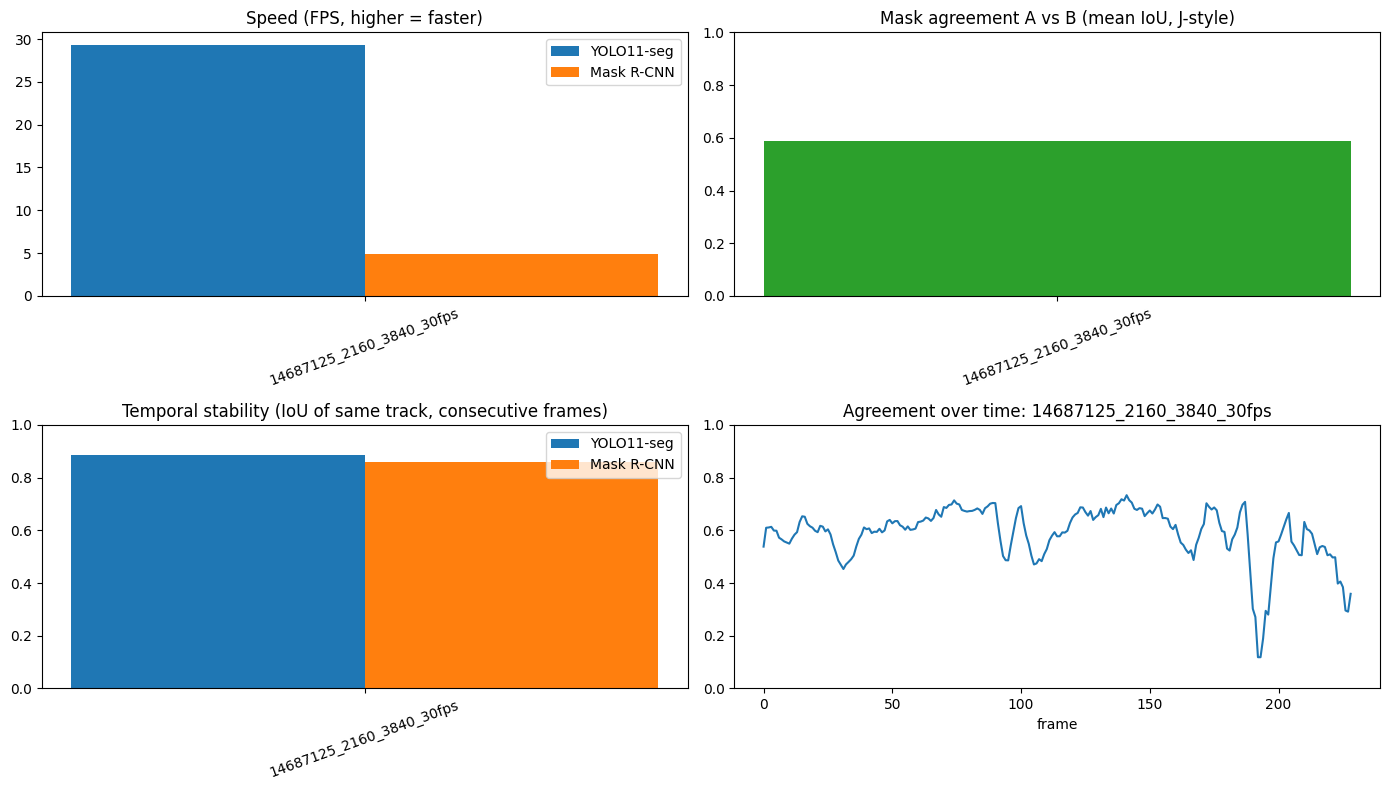

In [8]:
fig, ax = plt.subplots(2, 2, figsize=(14, 8))
x = np.arange(len(summary_df)); w = 0.38
lbl = summary_df.video.str.replace("pexels_", "")

ax[0, 0].bar(x - w/2, summary_df.fps_A, w, label=seg_a.short); ax[0, 0].bar(x + w/2, summary_df.fps_B, w, label=seg_b.short)
ax[0, 0].set_title("Speed (FPS, higher = faster)"); ax[0, 0].legend()

ax[0, 1].bar(x, summary_df.agreement, color="tab:green"); ax[0, 1].set_ylim(0, 1)
ax[0, 1].set_title("Mask agreement A vs B (mean IoU, J-style)")

ax[1, 0].bar(x - w/2, summary_df.stability_A, w, label=seg_a.short); ax[1, 0].bar(x + w/2, summary_df.stability_B, w, label=seg_b.short)
ax[1, 0].set_ylim(0, 1); ax[1, 0].set_title("Temporal stability (IoU of same track, consecutive frames)"); ax[1, 0].legend()

first = next(iter(per_frame.values()))
ax[1, 1].plot(first.agree.rolling(5, min_periods=1).mean()); ax[1, 1].set_ylim(0, 1)
ax[1, 1].set_title(f"Agreement over time: {next(iter(per_frame))}"); ax[1, 1].set_xlabel("frame")

for a in ax.flat[:3]: a.set_xticks(x); a.set_xticklabels(lbl, rotation=20)
plt.tight_layout(); plt.savefig(OUT_DIR / "metrics.png", dpi=120); plt.show()

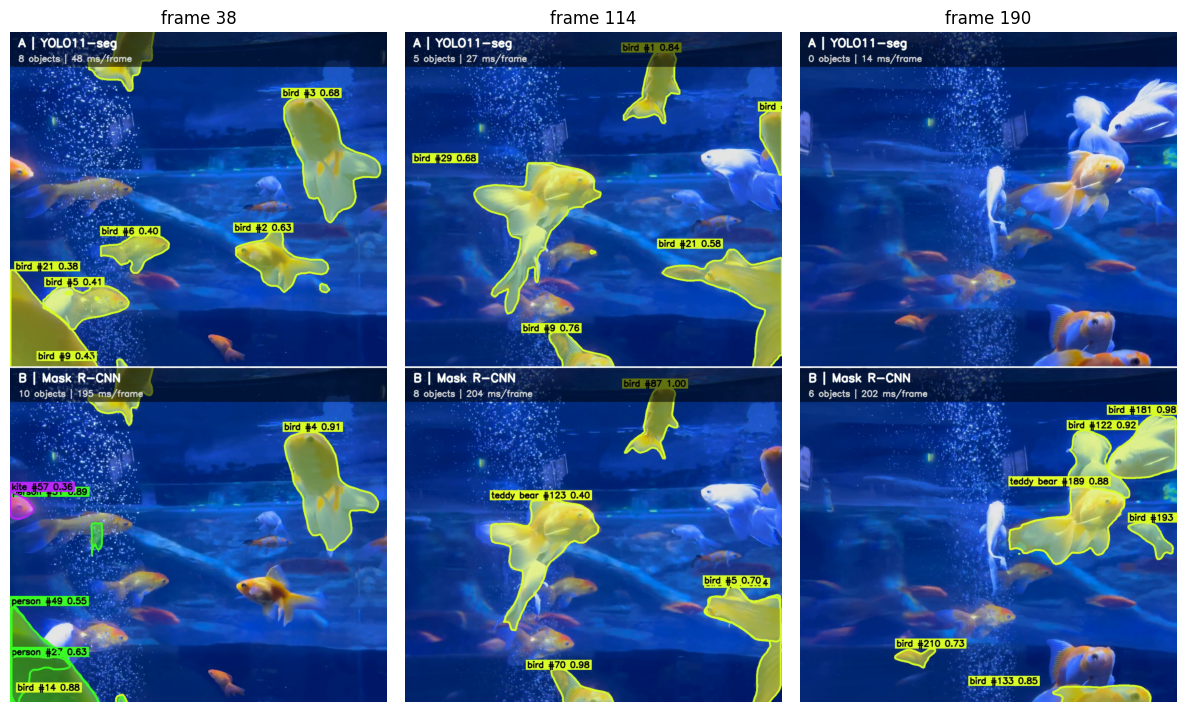

In [9]:
# Contact sheet: a few frames from the first output video
f = sorted(OUT_DIR.glob("*_split_*.mp4"))[0]
cap = cv2.VideoCapture(str(f)); n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fig, ax = plt.subplots(1, 3, figsize=(12, 7))
for a, idx in zip(ax, [n // 6, n // 2, 5 * n // 6]):
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx); ok, fr = cap.read()
    a.imshow(cv2.cvtColor(fr, cv2.COLOR_BGR2RGB)); a.axis("off"); a.set_title(f"frame {idx}")
cap.release(); plt.tight_layout(); plt.savefig(OUT_DIR / "contact_sheet.png", dpi=110); plt.show()

## How to read the numbers (and their limits)

* **Agreement is not accuracy.** Two models can agree and both be wrong. Treat it as a *disagreement finder*. Low-agreement frames and clips are where to look at the video.
* **Temporal stability depends on the tracker** as much as the segmenter (ByteTrack vs the simple IoU tracker here), so read it as "how steady does this whole pipeline look".
* **Speed** includes mask post-processing on CPU, so it reflects end-to-end cost, not just the network.
* COCO has 80 classes, so anything outside them (e.g. a skateboard ramp, food dishes) is simply not segmented by either model.

## Ideas to extend
1. **SAM 2** (Meta) is the modern, semi-supervised model in the article's OSVOS/MaskTrack spirit. Seed it with first-frame YOLO boxes as prompts and let it propagate masks through the video as model C.
2. **Real J&F scores:** run the same pipeline on **DAVIS 2016/2017** (the dataset from the article), which has ground-truth masks, and compute region similarity J and contour accuracy F.
3. Add a **third row**, or a *difference view* that colours pixels where A and B disagree.
4. Swap `LAYOUT="side"` to see the side-by-side variant, or `FIT="contain"` to avoid any cropping.
5. Try heavier weights (`yolo11x-seg.pt`) or a different `CONF` to see how the speed/quality trade-off moves.